In [1]:
import pandas as pd

# 导入数据
df = pd.read_csv('logic.csv')

# 查看前5行
print(df.head())

# 查看所有列名
print(df.columns.tolist())

   loanAmnt  term  subGrade  homeOwnership  verificationStatus    dti  \
0   35000.0     5        21              2                   2  17.05   
1   18000.0     5        16              0                   2  27.83   
2   12000.0     5        17              0                   2  22.77   
3   11000.0     3         3              1                   1  17.21   
4    3000.0     3        11              1                   2  32.16   

   ficoRangeLow   title        n2       n14  annualIncome_log  revol_flag  \
0         730.0     1.0  2.000000  2.000000         11.608245           1   
1         700.0  1723.0  5.646404  2.178891         10.736418           1   
2         675.0     0.0  3.000000  4.000000         11.211834           1   
3         685.0     4.0  6.000000  1.000000         11.678448           1   
4         690.0    11.0  7.000000  4.000000         10.275086           1   

   issueDateDT  creditAge  isDefault  
0         2587         13        1.0  
1         1888      

In [3]:
df.columns.tolist()

['loanAmnt',
 'term',
 'subGrade',
 'homeOwnership',
 'verificationStatus',
 'dti',
 'ficoRangeLow',
 'title',
 'n2',
 'n14',
 'annualIncome_log',
 'revol_flag',
 'issueDateDT',
 'creditAge',
 'isDefault']

In [5]:
# 转换为整数
df['loanAmnt'] = df['loanAmnt'].astype(int)
df['n2'] = df['n2'].astype(int)
df['n14'] = df['n14'].astype(int)
df['isDefault'] = df['isDefault'].astype(int)

# 查看数据类型
print(df.dtypes)

# 查看前5行
print(df.head())

# 查看指定列的数据类型
print("\n转换后的类型：")
print(df[['loanAmnt', 'n2', 'n14', 'isDefault']].dtypes)

loanAmnt                int32
term                    int64
subGrade                int64
homeOwnership           int64
verificationStatus      int64
dti                   float64
ficoRangeLow          float64
title                 float64
n2                      int32
n14                     int32
annualIncome_log      float64
revol_flag              int64
issueDateDT             int64
creditAge               int64
isDefault               int32
dtype: object
   loanAmnt  term  subGrade  homeOwnership  verificationStatus    dti  \
0     35000     5        21              2                   2  17.05   
1     18000     5        16              0                   2  27.83   
2     12000     5        17              0                   2  22.77   
3     11000     3         3              1                   1  17.21   
4      3000     3        11              1                   2  32.16   

   ficoRangeLow   title  n2  n14  annualIncome_log  revol_flag  issueDateDT  \
0         730.0   

In [7]:
df.head()

,loanAmnt,term,subGrade,homeOwnership,verificationStatus,dti,ficoRangeLow,title,n2,n14,annualIncome_log,revol_flag,issueDateDT,creditAge,isDefault
0,35000,5,21,2,2,17.05,730.0,1.0,2,2,11.608245,1,2587,13,1
1,18000,5,16,0,2,27.83,700.0,1723.0,5,2,10.736418,1,1888,10,0
2,12000,5,17,0,2,22.77,675.0,0.0,3,4,11.211834,1,3044,9,0
3,11000,3,3,1,1,17.21,685.0,4.0,6,1,11.678448,1,2983,16,0
4,3000,3,11,1,2,32.16,690.0,11.0,7,4,10.275086,1,3196,39,0


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('isDefault', axis=1)
y = df['isDefault']

# 第一步：划分训练集70%，剩余30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y  # 保持违约率比例一致
)

# 第二步：将剩余30%划分为验证集20%和测试集10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,   # 10%/(20%+10%)=1/3
    random_state=42,
    stratify=y_temp
)

# 查看数据集大小
print("训练集:", X_train.shape, y_train.shape)
print("验证集:", X_val.shape, y_val.shape)
print("测试集:", X_test.shape, y_test.shape)

# 查看违约率是否保持一致
print("\n违约率：")
print("总体:", y.mean())
print("训练集:", y_train.mean())
print("验证集:", y_val.mean())
print("测试集:", y_test.mean())

训练集: (358320, 14) (358320,)
验证集: (102377, 14) (102377,)
测试集: (51189, 14) (51189,)

违约率：
总体: 0.19596355438515606
训练集: 0.19596450100468854
验证集: 0.1959619836486711
测试集: 0.19596006954619155


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE后样本分布：")
print(y_train_res.value_counts())

SMOTE后样本分布：
isDefault
1    288102
0    288102
Name: count, dtype: int64


Validation AUC = 0.700029


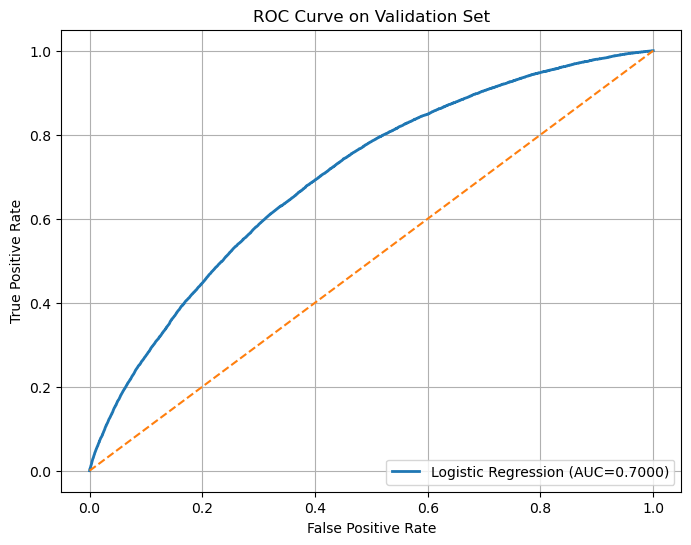

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# =========================
# 1. 训练逻辑回归模型
# =========================

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

# =========================
# 2. 验证集预测概率
# =========================

y_val_pred_proba = lr.predict_proba(X_val)[:, 1]

# =========================
# 3. 计算AUC
# =========================

auc_score = roc_auc_score(y_val, y_val_pred_proba)

print("="*50)
print(f"Validation AUC = {auc_score:.6f}")
print("="*50)

# =========================
# 4. ROC曲线
# =========================

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_pred_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC={auc_score:.4f})'
)

# 随机分类器参考线
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Validation Set')
plt.legend(loc='lower right')

plt.grid(True)

plt.show()

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import learning_curve

# =========================
# 1. 逻辑回归参数调优
# =========================

C_values = [0.01, 0.1, 1, 10]
penalties = ['l1', 'l2']
solvers = ['liblinear']

best_auc = 0
best_params = {}
best_model = None

results = []

for C, penalty, solver in itertools.product(C_values, penalties, solvers):
    
    lr = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        max_iter=1000,
        random_state=42
    )
    
    lr.fit(X_train, y_train)
    
    y_val_pred_proba = lr.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_pred_proba)
    
    results.append([C, penalty, solver, val_auc])
    
    print(f"C={C}, penalty={penalty}, solver={solver}, 验证集AUC={val_auc:.6f}")
    
    if val_auc > best_auc:
        best_auc = val_auc
        best_params = {
            'C': C,
            'penalty': penalty,
            'solver': solver
        }
        best_model = lr

print("\n==============================")
print("最优参数：", best_params)
print(f"最佳验证集 AUC = {best_auc:.6f}")
print("==============================")

# 保存调参结果
result_df = pd.DataFrame(
    results,
    columns=['C', 'penalty', 'solver', 'Validation_AUC']
)

print(result_df.sort_values(by='Validation_AUC', ascending=False))

C=0.01, penalty=l1, solver=liblinear, 验证集AUC=0.711124
C=0.01, penalty=l2, solver=liblinear, 验证集AUC=0.708141
C=0.1, penalty=l1, solver=liblinear, 验证集AUC=0.711483
C=0.1, penalty=l2, solver=liblinear, 验证集AUC=0.702476
C=1, penalty=l1, solver=liblinear, 验证集AUC=0.711646
C=1, penalty=l2, solver=liblinear, 验证集AUC=0.702476
C=10, penalty=l1, solver=liblinear, 验证集AUC=0.711646
C=10, penalty=l2, solver=liblinear, 验证集AUC=0.702477

最优参数： {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
最佳验证集 AUC = 0.711646
       C penalty     solver  Validation_AUC
6  10.00      l1  liblinear        0.711646
4   1.00      l1  liblinear        0.711646
2   0.10      l1  liblinear        0.711483
0   0.01      l1  liblinear        0.711124
1   0.01      l2  liblinear        0.708141
7  10.00      l2  liblinear        0.702477
3   0.10      l2  liblinear        0.702476
5   1.00      l2  liblinear        0.702476


In [20]:
# =========================
# 2. 测试集预测
# =========================

y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_pred_proba)

print("="*50)
print(f"Test AUC = {test_auc:.6f}")
print("="*50)

Test AUC = 0.709331


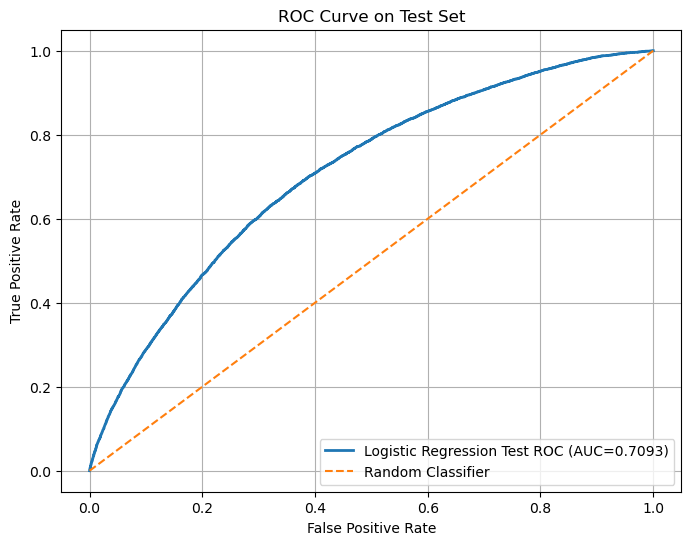

In [21]:
# =========================
# 3. 测试集 ROC 曲线
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression Test ROC (AUC={test_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# =========================
# 4. 学习曲线
# =========================

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training AUC'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Cross-validation AUC'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Training Sample Size')
plt.ylabel('AUC')
plt.title('Learning Curve of Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()